<a href="https://colab.research.google.com/github/brainExplorer/knn-svm-decision-tree-study/blob/main/knn_svm_dt_df.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Choosing the Best Algorithm in Classification Problems: A Comparative Pipeline with KNN, SVM, Decision Tree, and Random Forest

In this project, we will implement all the critical steps** used in real-world data science projects:

- Discovering data (EDA)
- Prevent data leakage (data leakage)
- Stratified train-test partition
- Hyperparameter optimization (RandomizedSearchCV)
- Model comparison (KNN, SVM, Decision Tree, Random Forest)
- Accurate metric selection (f1-macro)
- Model-agnostic feature importance
- Model Save (production ready)

Goal: Classify wine samples to 3 different types (cultivar).

In [ ]:
# =============================================================
# REQUIRED LIBRARY
# =============================================================

libraries = {
    "numpy" : "import numpy as np",
    "pandas" : "import pandas as pd",
    "matplotlib" : "import matplotlib.pyplot as plt",
    "seaborn" : "import seaborn as sns",
    "time" : "import time",
    "joblib" : "import joblib",
    "warnings" : "import warnings",
    "warning filter" : "warnings.filterwarnings(\"ignore\")",
    "wine dataset" : "from sklearn.datasets import load_wine",
    "train-test split" : "from sklearn.model_selection import (train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold)",
    "StandardScaler" : "from sklearn.preprocessing import StandardScaler",
    "PipeLine" : "from sklearn.pipeline import Pipeline",
    "neighbors" : "from sklearn.neighbors import KNeighborsClassifier",
    "svm" : "from sklearn.svm import SVC",
    "tree" : "from sklearn.tree import DecisionTreeClassifier",
    "ensemble" : "from sklearn.ensemble import RandomForestClassifier",
    "metrics" : "from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)",
    "feature importance" : "from sklearn.inspection import permutation_importance",
    "stats" : "from scipy.stats import (randint, uniform, loguniform)",
}


for name, command in libraries.items():
    try:
        exec(command)
        print(f"{name} imported successfully.")
    except ImportError:
        print(f"Failed to import {name}.")
    except Exception as e:
        print(f"An error occurred while importing {name}: {e}")
    finally:
        print("=" * 50)




numpy imported successfully.
pandas imported successfully.
matplotlib imported successfully.
seaborn imported successfully.
time imported successfully.
joblib imported successfully.
warnings imported successfully.
warning filter imported successfully.
wine dataset imported successfully.
train-test split imported successfully.
StandardScaler imported successfully.
PipeLine imported successfully.
neighbors imported successfully.
svm imported successfully.
tree imported successfully.
ensemble imported successfully.
metrics imported successfully.
feature importance imported successfully.
stats imported successfully.


## Load Data and Exploratory Data Analysis

In real life, the first thing we need to do as soon as we receive data is to **identify** it:

- How many samples, how many features?
- Are the classes balanced? (If there is imbalance, we need to make metric selection and <code>class_weight</code> settings.)
- Are there outliers? (Determines the scaling method.)

This step affects all our decisions, from model selection to hyperparameter optimization. Don't skip it!

In [ ]:
# ====================================================================================
# Load Data and Exploratory Data Analysis
# ====================================================================================

data = load_wine()
X = data.data
y = data.target
feature_names = data.feature_names

print("="*30)
print("Exploratory Data Analysis(EDA)")
print("="*30)

print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

unique, counts = np.unique(y, return_counts=True)

print("Class distribution:")

for cls, cnt in zip(data.target_names, counts):
    print(f"{cls}: {cnt}")

print("="*30)

# Interquartile Range (IQR)
Q1 = np.percentile(X, 25, axis=0)
Q3 = np.percentile(X, 75, axis=0)
IQR = Q3 - Q1
#The Interquartile Range (IQR) is a robust statistical metric used in Machine Learning preprocessing to detect and
#filter data outliers by measuring the statistical spread of the middle 50% of your dataset.
outlier_ratio = np.mean(((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1))
print(f"Potential outlier ratio: {outlier_ratio * 100:.2f}%")


Exploratory Data Analysis(EDA)
Number of samples: 178
Number of features: 13
Class distribution:
class_0: 59
class_1: 71
class_2: 48
Potential outlier ratio: 9.55%


## Stratified Train-Test Splitting

It is crucial to **stratify** the data when splitting it into training and test sets.

This ensures that the test set maintains the same class distribution as the training set.

This is essential for accurately measuring model performance, especially in small datasets or unbalanced classes.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Class distribution in training set: {np.bincount(y_train)}")
print(f"Class distribution in test set: {np.bincount(y_test)}")


Training set: 142 samples
Test set: 36 samples
Class distribution in training set: [47 57 38]
Class distribution in test set: [12 14 10]


## Model Definition and Hyperparameter Spaces

We selected four different algorithms:
- **KNN** (distance-based, scaling required)
- **SVM** (scaling required, kernel selection important)
- **Decision Tree** (no scaling required, pruning parameters)
- **Random Forest** (no scaling required, ensemble parameters)

**Critical Point:** We place the scaler (StandardScaler) inside the **Pipeline**.

This is to ensure that during Cross-Validation, scaling is applied only to the training data in each fold.

If you fit the scaler outside, information from the test fold will leak into the training data (data leakage) – this is a major mistake!

Also, we use `class_weight='balanced'` in all models against unbalanced classes.

In [ ]:
# ==============================================================
# MODELS AND HYPERPARAMETER SPACES
# =================================================================
models = {
    'KNN': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier())
        ]),
        'param_dist': {
            'clf__n_neighbors': randint(3, 30),
            'clf__weights': ['uniform', 'distance'],
            'clf__metric': ['euclidean', 'manhattan'],
            'clf__p': [1, 2]
        }
    },
    'SVM': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(random_state=42, class_weight='balanced'))
        ]),
        'param_dist': {
            'clf__C': loguniform(0.01, 100),
            'clf__gamma': loguniform(0.001, 1),
            'clf__kernel': ['rbf', 'poly']
        }
    },
    'Decision Tree': {
        'pipeline': Pipeline([
            ('clf', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
        ]),
        'param_dist': {
            'clf__max_depth': randint(3, 20),
            'clf__min_samples_split': randint(2, 20),
            'clf__min_samples_leaf': randint(1, 10),
            'clf__criterion': ['gini', 'entropy'],
            'clf__ccp_alpha': uniform(0, 0.05)
        }
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
        ]),
        'param_dist': {
            'clf__n_estimators': randint(50, 300),
            'clf__max_depth': randint(5, 30),
            'clf__min_samples_split': randint(2, 15),
            'clf__max_features': ['sqrt', 'log2', None],
            'clf__ccp_alpha': uniform(0, 0.01)
        }
    }
}

print("✅ 4 model and parameter spaces defined.")

✅ 4 model and parameter spaces defined.


## Hyperparameter Optimization (RandomizedSearchCV)

We use **RandomizedSearch** instead of GridSearch because:
- The parameter space is large and contains continuous values.
- 30 random combinations generally yield results as good as many combinations in GridSearch.
- It saves a lot of time and computational costs.

**We chose `f1_macro` as the metric.**

Why? Because accuracy is misleading if the classes are not balanced.

`f1_macro` takes the average of the F1 scores of each class and gives equal importance to all classes.

We also maintain class balance in Cross-Validation by using `StratifiedKFold`.

In [ ]:
# ================================================================
# HYPERPARAMETER OPTIMIZATION (RandomizedSearchCV)
# ================================================================

best_pipelines = {}
results = []

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, config in models.items():
  print("\n" + "="*60)
  print(f"🚀 Optimization started: {name}")
  print("="*60)
  start_time = time.time()

  random_search = RandomizedSearchCV(
      estimator=config['pipeline'],
      param_distributions=config['param_dist'],
      n_iter=30,
      cv=cv_strategy,
      scoring='f1_macro',
      verbose=0,
      n_jobs=-1,
      random_state=42
  )

  random_search.fit(X_train, y_train)
  elapsed = time.time() - start_time

  best_model = random_search.best_estimator_
  best_pipelines[name] = best_model

  cv_mean = random_search.best_score_
  cv_std = random_search.cv_results_['std_test_score'][random_search.best_index_]

  y_pred = best_model.predict(X_test)
  test_f1 = f1_score(y_test, y_pred, average='macro')
  test_accuracy = accuracy_score(y_test, y_pred)

  results.append({
      'Model': name,
      'Best Parameters': random_search.best_params_,
      'CV F1-Macro': f"{cv_mean:.4f} ± {cv_std:.4f}",
      'Test F1-Macro': f"{test_f1:.4f}",
      'Test Accuracy': f"{test_accuracy:.4f}",
      'Training Time': f"{elapsed:.2f} seconds"
  })


print(f" Best parameters: {random_search.best_params_}")
print(f" CV F1-macro: {cv_mean:.4f} (±{cv_std:.4f})")
print(f" Test F1-macro: {test_f1:.4f}")
print("\nClassification Report (test):")
print(classification_report(y_test, y_pred, target_names=data.target_names))


🚀 Optimization started: KNN

🚀 Optimization started: SVM

🚀 Optimization started: Decision Tree

🚀 Optimization started: Random Forest
 Best parameters: {'clf__ccp_alpha': np.float64(0.008661761457749353), 'clf__max_depth': 8, 'clf__max_features': None, 'clf__min_samples_split': 7, 'clf__n_estimators': 102}
 CV F1-macro: 0.9789 (±0.0285)
 Test F1-macro: 1.0000

Classification Report (test):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## Model Comparison Table

Now we can compare the performance and training times of all models.

Which model has the best F1 macro score? Which model is the fastest?

This table is a reference source for model selection in the real world.

In [ ]:
# ===============================================================
# RESULTS TABLE
# ================================================================
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("📊 PERFORMANCE COMPARISON OF ALL MODELS")
print("="*60)
print(results_df[['Model', 'Test F1-Macro', 'Test Accuracy', 'CV F1-Macro', 'Training Time']].to_string(index=False))


📊 PERFORMANCE COMPARISON OF ALL MODELS
        Model Test F1-Macro Test Accuracy     CV F1-Macro Training Time
          KNN        0.9743        0.9722 0.9726 ± 0.0252  3.33 seconds
          SVM        0.9407        0.9444 0.9939 ± 0.0121  0.96 seconds
Decision Tree        0.9743        0.9722 0.9034 ± 0.0406  0.93 seconds
Random Forest        1.0000        1.0000 0.9789 ± 0.0285 47.02 seconds


## Confusion Matrices (Error Analysis)

A confusion matrix shows which classes the model is mixing together.

For example, which wine types are similar to each other? This information guides improvement.

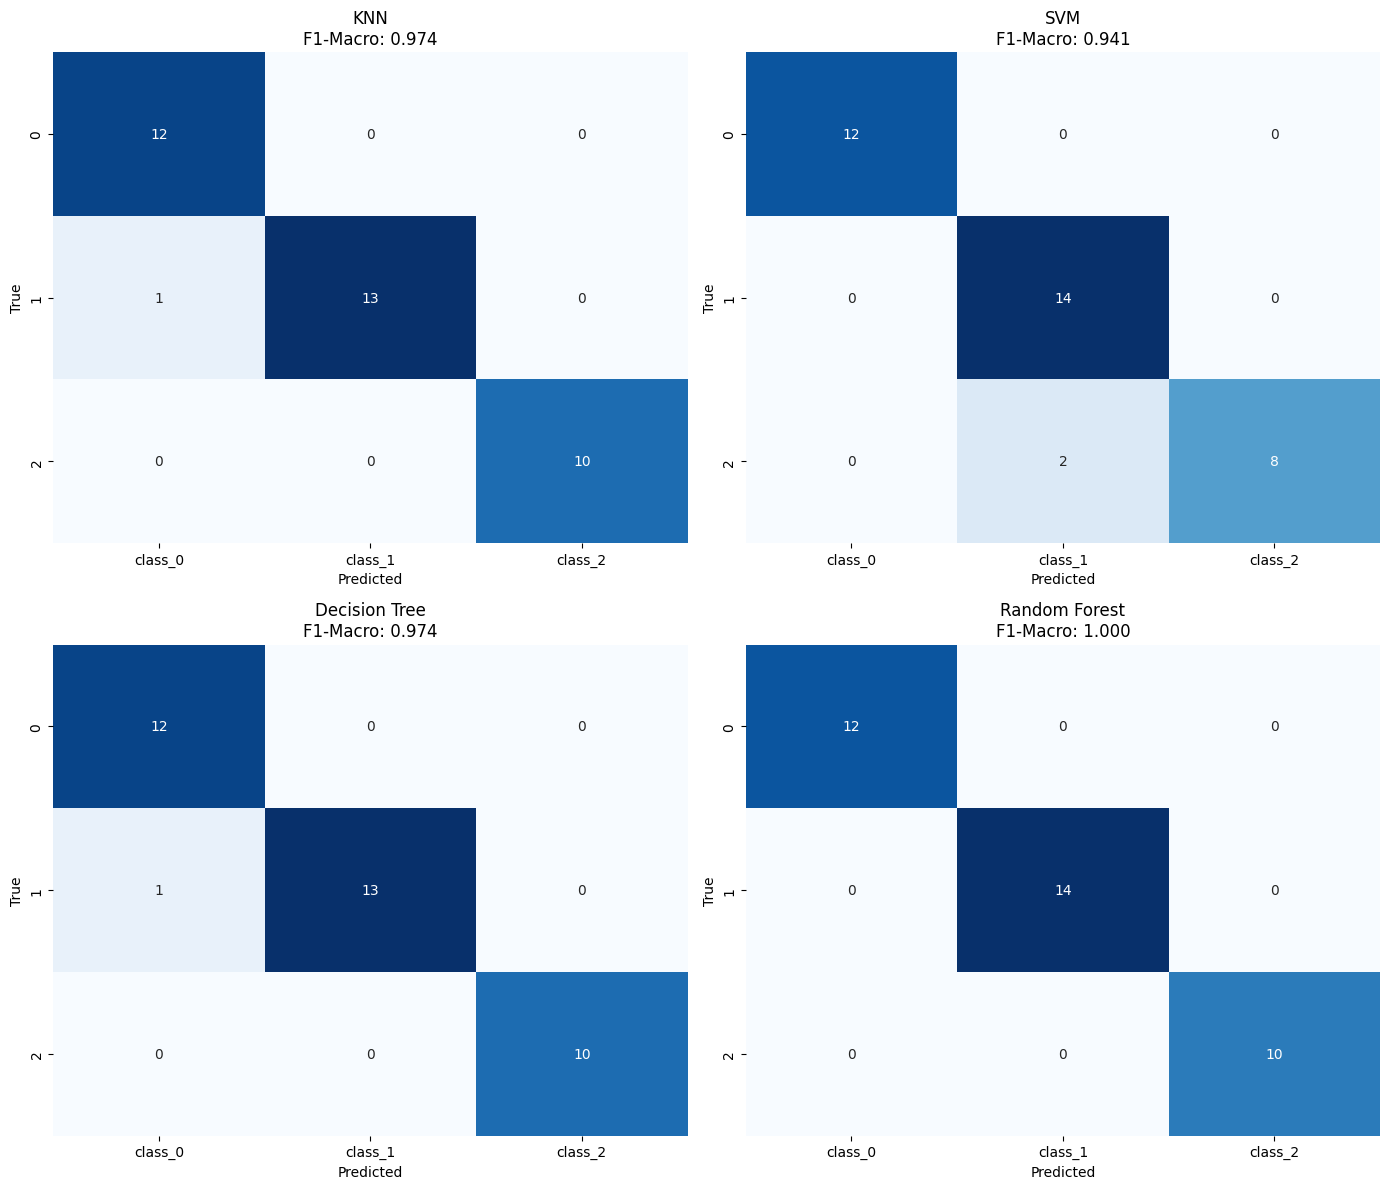

✅ Confusion matrices saved as 'confusion_matrices.png'


In [ ]:
# ================================================================================
# CONFUSION MATRICES
# ================================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(best_pipelines.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=data.target_names, cbar=False)
    axes[idx].set_title(f'{name}\nF1-Macro: {f1_score(y_test, y_pred, average="macro"):.3f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=200)
plt.show()
print("✅ Confusion matrices saved as 'confusion_matrices.png'")

## Permutation Feature Importance (Model-agnostic)

Tree models assign their own feature importance, but this is not possible for KNN and SVM.

**Permutation importance** works for any model:

We measure how much the model score drops by randomly shuffling the values ​​of a feature.

A large drop = the feature is important.

These graphs are perfect for explaining to business stakeholders which features (e.g., alcohol percentage) are critical for the model.

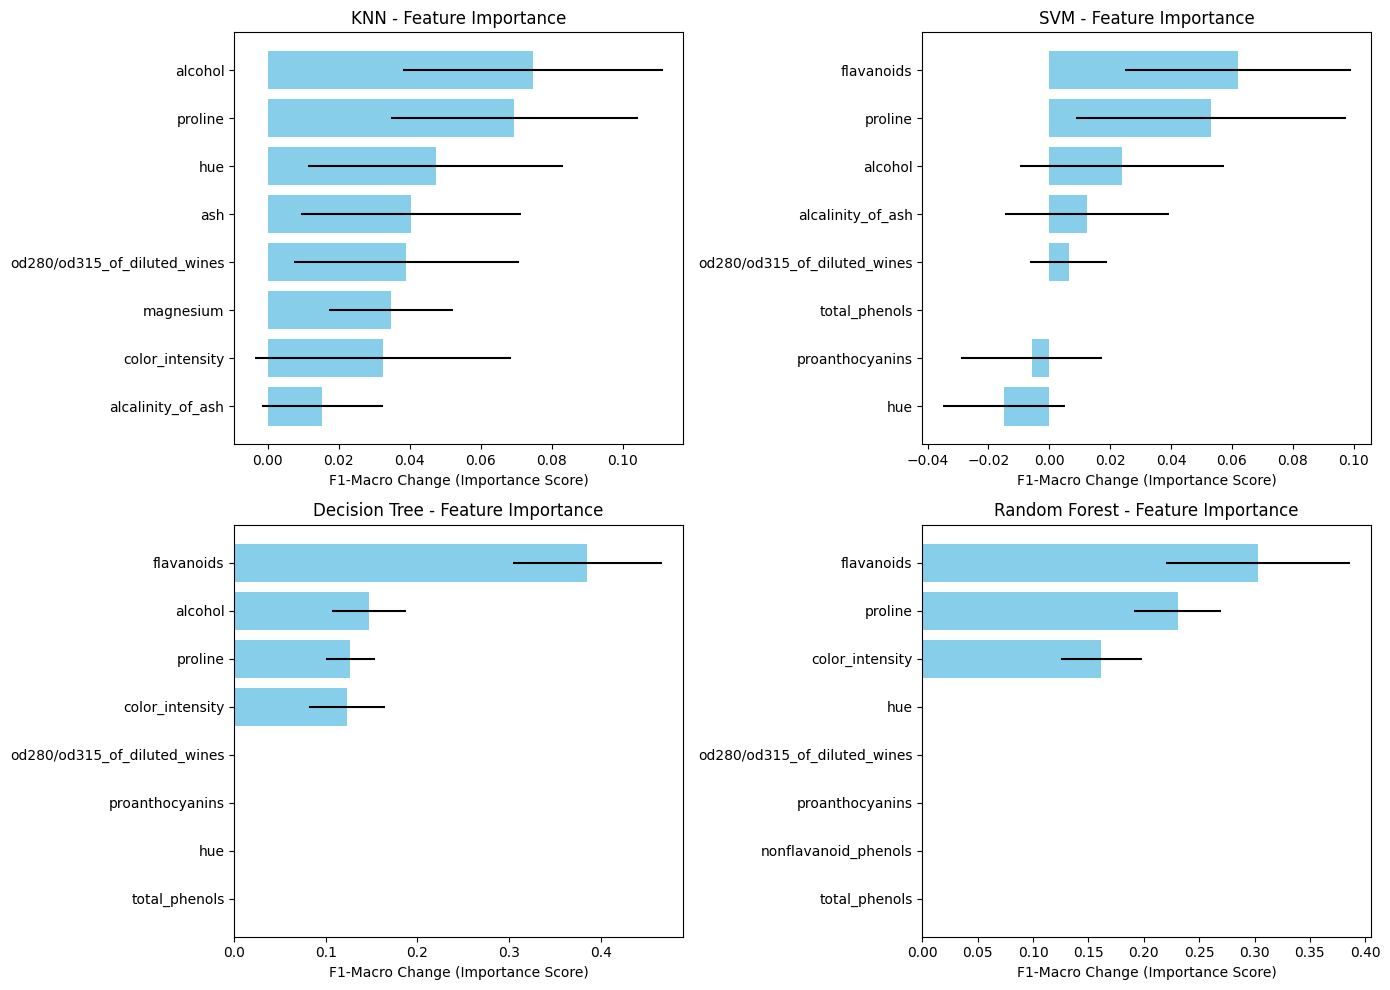

✅ Permutation feature importance saved as 'permutation_feature_importance.png'


In [ ]:
# ================================================================
# PERMUTATION FEATURE IMPORTANCE
# ================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(best_pipelines.items()):
    perm_importance = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
    )
    sorted_idx = np.argsort(perm_importance.importances_mean)[::-1]
    sorted_features = [feature_names[i] for i in sorted_idx]
    sorted_importances = perm_importance.importances_mean[sorted_idx]
    sorted_stds = perm_importance.importances_std[sorted_idx]

    axes[idx].barh(sorted_features[:8], sorted_importances[:8], xerr=sorted_stds[:8], color='skyblue')
    axes[idx].set_title(f'{name} - Feature Importance')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('F1-Macro Change (Importance Score)')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=200)
plt.show()
print("✅ Permutation feature importance saved as 'permutation_feature_importance.png'")



## Preparing the Best Model for Production

We select the model with the highest F1-macro score and save it with `joblib`.

This file can then be used in an API, web service, or batch processing system.

One line to load the model: `joblib.load('best_model.pkl')`

In [ ]:
#================================================================================
# SAVE THE BEST MODEL
# ================================================================================
best_model_name = results_df.iloc[results_df['Test F1-Macro'].astype(float).idxmax()]['Model']
best_model = best_pipelines[best_model_name]
joblib.dump(best_model, 'best_model.pkl')
print(f"🏆 Best model: {best_model_name}")
print(f" Test F1-macro: {results_df.loc[results_df['Model']==best_model_name, 'Test F1-Macro'].values[0]}")
print(" Model saved as 'best_model.pkl'.")

🏆 Best model: Random Forest
 Test F1-macro: 1.0000
 Model saved as 'best_model.pkl'.


## Bonus: Comparison of 'uniform' vs 'distance' in KNN

Theoretically, weighting by distance is better because it gives more importance to nearby neighbors.

However, this isn't always true – it depends on the dataset.

With this analysis, we'll compare the two methods with other hyperparameters that have been found to be best suited to this dataset.

In [ ]:
# ================================================================================
# KNN SPECIAL ANALYSIS: uniform vs distance
# ================================================================================
if 'KNN' in best_pipelines:
    best_knn_params = best_pipelines['KNN'].named_steps['clf'].get_params()
    knn_uniform = KNeighborsClassifier(**{**best_knn_params, 'weights':'uniform'})
    knn_distance = KNeighborsClassifier(**{**best_knn_params, 'weights':'distance'})

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    cv_uniform = cross_val_score(knn_uniform, X_train_scaled, y_train, cv=5, scoring='f1_macro')
    cv_distance = cross_val_score(knn_distance, X_train_scaled, y_train, cv=5, scoring='f1_macro')
    print("\n" + "="*60)
    print("🧪 KNN 'uniform' vs 'distance' COMPARISON")
    print("="*60)
    print(f"Uniform CV F1-macro: {cv_uniform.mean():.4f} (±{cv_uniform.std():.4f})")
    print(f"Distance CV F1-macro: {cv_distance.mean():.4f} (±{cv_distance.std():.4f})")
    if cv_distance.mean() > cv_uniform.mean():
      print("✅ 'distance' is more successful in this dataset!")
    else:
      print("✅ 'uniform' is more successful in this dataset!")

else:
    print("KNN model not found, skipped.")




🧪 KNN 'uniform' vs 'distance' COMPARISON
Uniform CV F1-macro: 0.9736 (±0.0254)
Distance CV F1-macro: 0.9796 (±0.0273)
✅ 'distance' is more successful in this dataset!


In [ ]:
## ✅ Project Completed!

You now have:
- Comparative model performance table
- Confusion matrix graph
- Feature importance graphs
- Best saved model (`best_model.pkl`)

This pipeline includes all best practices used in real-world projects.

You can use the same structure by adapting each step to your own dataset.

**Key takeaways:**
- Preventing data leakage with **Pipeline**
- **Stratified** splitting and CV
- **Choosing the right metric** (not accuracy, but f1-macro)**
- **Model-agnostic** feature importance
- Saving the model for **Production**

Good luck with your training! 🚀

SyntaxError: invalid character '🚀' (U+1F680) (657958661.py, line 20)